# Chapter 5: Classification

## Summary

Classification is one of the most important supervised machine learning tasks. Unlike regression, which predicts continuous values, classification predicts categorical outcomes.

This chapter introduces classification methods including Naive Bayes, Logistic Regression, and Discriminant Analysis. It also discusses classification evaluation metrics such as confusion matrices, precision, recall, specificity, ROC curves, and AUC.

Classification techniques are widely used in fraud detection, medical diagnosis, spam filtering, recommendation systems, and customer behavior analysis.

## Learning Objectives

After completing this chapter, students should be able to:

- Understand classification problems.
- Distinguish classification from regression.
- Explain Naive Bayes classification.
- Understand Logistic Regression.
- Interpret confusion matrices.
- Evaluate classification models.
- Understand ROC curves and AUC.
- Apply classification techniques in data science.

## Theory: Classification

Classification is a supervised learning task where the goal is to predict a categorical outcome.

Examples:

- Fraud or Non-Fraud
- Spam or Not Spam
- Disease or No Disease
- Customer Churn or Retained

Classification models learn patterns from labeled data and use these patterns to predict unseen observations.

Unlike regression, classification outputs categories rather than continuous values.

In [1]:
import pandas as pd

data = pd.DataFrame({
    'Age': [20,25,30,35,40,45,50,55],
    'Purchased': [0,0,0,1,1,1,1,1]
})

data

,Age,Purchased
0,20,0
1,25,0
2,30,0
3,35,1
4,40,1
5,45,1
6,50,1
7,55,1


## Theory: Logistic Regression

Logistic Regression is one of the most widely used classification algorithms.

Unlike linear regression, logistic regression predicts probabilities between 0 and 1.

The output probability can then be converted into a class label.

Examples:

Probability > 0.5 → Class 1

Probability ≤ 0.5 → Class 0

Logistic Regression is widely used because it is simple, interpretable, and computationally efficient.

In [2]:
from sklearn.linear_model import LogisticRegression

X = data[['Age']]
y = data['Purchased']

log_model = LogisticRegression()

log_model.fit(X, y)

predictions = log_model.predict(X)

print(predictions)

[0 0 0 1 1 1 1 1]


In [3]:
probabilities = log_model.predict_proba(X)

print(probabilities)

[[9.99903852e-01 9.61481392e-05]
 [9.96126479e-01 3.87352064e-03]
 [8.64114956e-01 1.35885044e-01]
 [1.35882605e-01 8.64117395e-01]
 [3.87344048e-03 9.96126560e-01]
 [9.61461420e-05 9.99903854e-01]
 [2.37773713e-06 9.99997622e-01]
 [5.87971262e-08 9.99999941e-01]]


## Code Explanation

The Logistic Regression model predicts whether a customer makes a purchase based on age.

The predict() function generates class labels.

The predict_proba() function generates probabilities for each class.

Probability estimates provide additional information about prediction confidence.

## Theory: Naive Bayes

Naive Bayes is a probabilistic classification algorithm based on Bayes' Theorem.

The algorithm assumes that predictor variables are independent of each other.

Despite this strong assumption, Naive Bayes often performs surprisingly well in practice.

Applications include:

- Spam filtering
- Text classification
- Sentiment analysis
- Document categorization

In [4]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X, y)

nb_predictions = nb_model.predict(X)

print(nb_predictions)

[0 0 0 1 1 1 1 1]


## Theory: Confusion Matrix

A Confusion Matrix summarizes the performance of a classification model.

The matrix contains four outcomes:

### True Positive (TP)

The model correctly predicts the positive class.

### True Negative (TN)

The model correctly predicts the negative class.

### False Positive (FP)

The model incorrectly predicts the positive class.

### False Negative (FN)

The model incorrectly predicts the negative class.

Confusion matrices provide detailed insight into classification performance.

In [5]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y,
    predictions
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[3 0]
 [0 5]]


In [6]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y,
    predictions
)

print("Accuracy:")
print(accuracy)

Accuracy:
1.0


## Theory: Accuracy

Accuracy measures the proportion of correct predictions.

Formula:

Accuracy = Correct Predictions / Total Predictions

Although accuracy is easy to understand, it can be misleading when classes are imbalanced.

For example, in fraud detection where fraud cases are rare, a model may achieve high accuracy while failing to detect fraud.

In [7]:
from sklearn.metrics import (
    precision_score,
    recall_score
)

precision = precision_score(
    y,
    predictions
)

recall = recall_score(
    y,
    predictions
)

print("Precision:")
print(precision)

print("\nRecall:")
print(recall)

Precision:
1.0

Recall:
1.0


## Theory: Precision and Recall

### Precision

Precision measures how many predicted positive cases are actually positive.

Formula:

Precision = TP / (TP + FP)

### Recall

Recall measures how many actual positive cases are correctly identified.

Formula:

Recall = TP / (TP + FN)

Precision and Recall are particularly important in imbalanced datasets such as fraud detection and medical diagnosis.

In [9]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

prob_positive = probabilities[:, 1]

auc = roc_auc_score(
    y,
    prob_positive
)

print("AUC Score:")
print(auc)

AUC Score:
1.0


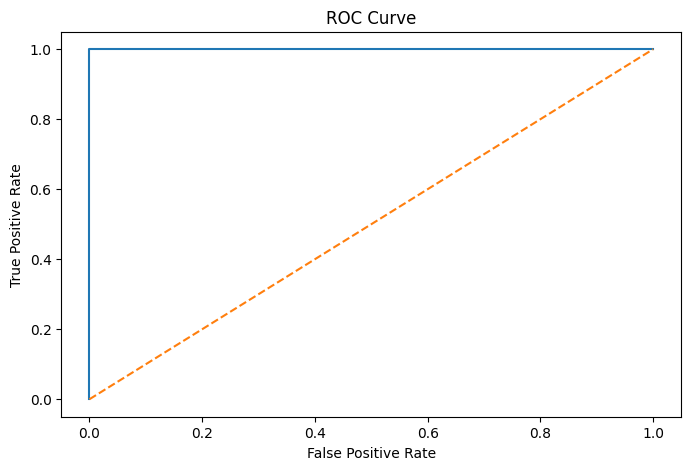

In [10]:
fpr, tpr, thresholds = roc_curve(
    y,
    prob_positive
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    fpr,
    tpr
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

## Theory: ROC Curve and AUC

### ROC Curve

The Receiver Operating Characteristic (ROC) Curve evaluates classification performance across different thresholds.

The ROC Curve plots:

- True Positive Rate
- False Positive Rate

### AUC

Area Under the Curve (AUC) summarizes the ROC Curve into a single value.

Interpretation:

- AUC = 1.0 → Perfect Model
- AUC = 0.5 → Random Guessing

Higher AUC values indicate better classification performance.

## Discussion

Classification models predict categorical outcomes and are widely used in real-world applications.

Logistic Regression and Naive Bayes are simple yet powerful classification techniques.

Evaluation metrics such as Accuracy, Precision, Recall, ROC Curves, and AUC provide deeper insights than accuracy alone.

In practical machine learning projects, selecting appropriate evaluation metrics is essential for building reliable classification systems.

## Theory: Discriminant Analysis

Discriminant Analysis is a classification technique that models differences between classes based on predictor variables.

The objective is to find boundaries that best separate different classes.

A commonly used approach is:

### Linear Discriminant Analysis (LDA)

LDA assumes that predictor variables follow a normal distribution and that classes share the same covariance matrix.

LDA is often used in:

- Medical diagnosis
- Image recognition
- Pattern classification
- Customer segmentation

In [11]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_model = LinearDiscriminantAnalysis()

lda_model.fit(X, y)

lda_predictions = lda_model.predict(X)

print("LDA Predictions:")
print(lda_predictions)

LDA Predictions:
[0 0 0 1 1 1 1 1]


## Theory: Rare Class Problem

Many real-world classification problems contain rare classes.

Examples include:

- Fraud Detection
- Disease Diagnosis
- Network Intrusion Detection
- Credit Card Fraud

In these situations, the positive class occurs much less frequently than the negative class.

This imbalance can make classification more difficult and may lead to misleading performance metrics.

## Theory: Imbalanced Data

Imbalanced datasets occur when one class significantly outnumbers another.

Example:

- Non-Fraud = 95%
- Fraud = 5%

A model predicting all observations as non-fraud could achieve 95% accuracy while completely failing to identify fraud cases.

For this reason, additional evaluation metrics are required beyond accuracy.

## Theory: Oversampling and Undersampling

Several techniques can address class imbalance.

### Oversampling

Increases the number of minority class observations.

Examples:

- Random Oversampling
- SMOTE

### Undersampling

Reduces the number of majority class observations.

Examples:

- Random Undersampling

Both techniques aim to improve model performance on minority classes.

In [12]:
class_counts = data['Purchased'].value_counts()

print("Class Distribution:")
print(class_counts)

Class Distribution:
Purchased
1    5
0    3
Name: count, dtype: int64


## Applications of Classification

Classification algorithms are widely applied across many domains.

Examples include:

### Finance

- Credit Scoring
- Fraud Detection
- Loan Approval

### Healthcare

- Disease Prediction
- Medical Diagnosis

### Marketing

- Customer Churn Prediction
- Purchase Prediction

### Cybersecurity

- Spam Detection
- Intrusion Detection

## Machine Learning Connection

Classification is one of the most widely used machine learning tasks.

Popular classification algorithms include:

- Logistic Regression
- Naive Bayes
- Decision Trees
- Random Forest
- Support Vector Machines
- Gradient Boosting

These methods enable organizations to automate decision-making and improve predictive performance.

## Discussion

Classification techniques transform historical data into predictive systems capable of assigning observations to predefined categories.

Logistic Regression, Naive Bayes, and Linear Discriminant Analysis provide different approaches to classification problems.

Evaluation metrics such as Precision, Recall, ROC Curves, and AUC help assess model quality, especially in imbalanced datasets.

Understanding classification methods is essential for solving many practical machine learning problems.

## Conclusion

Classification is a fundamental machine learning task used to predict categorical outcomes.

This chapter introduced Logistic Regression, Naive Bayes, Discriminant Analysis, Confusion Matrices, Precision, Recall, ROC Curves, AUC, and techniques for handling imbalanced data.

These methods provide powerful tools for building predictive systems across finance, healthcare, marketing, and cybersecurity applications.

A strong understanding of classification techniques forms an essential foundation for advanced machine learning algorithms.